```

Estrutura da Segmentação

1.  Imports e carregamento do dataset limpo
2.  Definir a data de referência
3.  Calcular Recency
4.  Calcular Frequency
5.  Calcular Monetary
6.  Unir as 3 métricas — tabela RFM
7.  Explorar a distribuição do RFM
8.  Normalizar os dados
9.  Definir o número ideal de clusters (método Elbow)
10. Treinar o K-Means
11. Analisar os segmentos gerados
12. Nomear os segmentos
13. Visualizar os segmentos
14. Salvar o modelo e o dataset segmentado

### Célula 1 — Imports e carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('../data/processed/online_retail_clean.csv',
                 parse_dates=['InvoiceDate'])

print(f"Dataset carregado: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"\nPeríodo: {df['InvoiceDate'].min().date()} até {df['InvoiceDate'].max().date()}")

Dataset carregado: 770,715 linhas x 9 colunas

Período: 2009-12-01 até 2011-12-09


### Célula 2 — Definir a data de referência

In [2]:
# A data de referência é o ponto a partir do qual calculamos
# quantos dias faz que o cliente comprou pela última vez (Recency)
# Usamos o dia seguinte à última transação do dataset

data_referencia = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f"Última transação no dataset: {df['InvoiceDate'].max().date()}")
print(f"Data de referência adotada:  {data_referencia.date()}")

Última transação no dataset: 2011-12-09
Data de referência adotada:  2011-12-10


### Célula 3 — Calcular Recency

In [3]:
recency = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency.columns = ['Customer ID', 'UltimaCompra']
recency['Recency'] = (data_referencia - recency['UltimaCompra']).dt.days

print(f"Recency calculado para {len(recency):,} clientes")
print(f"\nDistribuição:")
print(f"Mínimo:  {recency['Recency'].min()} dias")
print(f"Mediana: {recency['Recency'].median():.0f} dias")
print(f"Média:   {recency['Recency'].mean():.0f} dias")
print(f"Máximo:  {recency['Recency'].max()} dias")
print(f"\nExemplo:")
recency.head()

Recency calculado para 5,816 clientes

Distribuição:
Mínimo:  1 dias
Mediana: 95 dias
Média:   201 dias
Máximo:  739 dias

Exemplo:


,Customer ID,UltimaCompra,Recency
0,12346,2010-06-28 13:53:00,529
1,12347,2011-12-07 15:52:00,2
2,12348,2011-09-25 13:13:00,75
3,12349,2011-11-21 09:51:00,19
4,12350,2011-02-02 16:01:00,310


### Célula 4 — Calcular Frequency

In [4]:
frequency = df.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency.columns = ['Customer ID', 'Frequency']

print(f"Frequency calculado para {len(frequency):,} clientes")
print(f"\nDistribuição:")
print(f"Mínimo:  {frequency['Frequency'].min()} pedidos")
print(f"Mediana: {frequency['Frequency'].median():.0f} pedidos")
print(f"Média:   {frequency['Frequency'].mean():.0f} pedidos")
print(f"Máximo:  {frequency['Frequency'].max()} pedidos")
print(f"\nExemplo:")
frequency.head()

Frequency calculado para 5,816 clientes

Distribuição:
Mínimo:  1 pedidos
Mediana: 3 pedidos
Média:   6 pedidos
Máximo:  373 pedidos

Exemplo:


,Customer ID,Frequency
0,12346,3
1,12347,8
2,12348,5
3,12349,3
4,12350,1


### Célula 5 — Calcular Monetary

In [5]:
monetary = df.groupby('Customer ID')['TotalPrice'].sum().reset_index()
monetary.columns = ['Customer ID', 'Monetary']

print(f"Monetary calculado para {len(monetary):,} clientes")
print(f"\nDistribuição:")
print(f"Mínimo:  £{monetary['Monetary'].min():.2f}")
print(f"Mediana: £{monetary['Monetary'].median():.2f}")
print(f"Média:   £{monetary['Monetary'].mean():.2f}")
print(f"Máximo:  £{monetary['Monetary'].max():.2f}")
print(f"\nExemplo:")
monetary.head()

Monetary calculado para 5,816 clientes

Distribuição:
Mínimo:  £2.90
Mediana: £829.12
Média:   £2464.30
Máximo:  £336091.92

Exemplo:


,Customer ID,Monetary
0,12346,170.36
1,12347,4671.93
2,12348,1658.40
3,12349,3678.69
4,12350,294.40


### Célula 6 — Unir as 3 métricas — tabela RFM

In [6]:
rfm = recency[['Customer ID', 'Recency']].merge(
    frequency, on='Customer ID').merge(
    monetary, on='Customer ID')

print(f"Tabela RFM criada: {rfm.shape[0]:,} clientes x {rfm.shape[1]} colunas")
print(f"\nPrimeiros registros:")
rfm.head(10)

Tabela RFM criada: 5,816 clientes x 4 colunas

Primeiros registros:


,Customer ID,Recency,Frequency,Monetary
0,12346,529,3,170.36
1,12347,2,8,4671.93
2,12348,75,5,1658.40
3,12349,19,3,3678.69
4,12350,310,1,294.40
5,12351,375,1,300.93
6,12352,36,9,1729.54
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


```
A tabela RFM está pronta — o coração do projeto materializado em 4 colunas simples.
Olha o que já conseguimos ler sem nenhum modelo:

Cliente 12347 → Recency=2,  Frequency=8,  Monetary=£4.671 → VIP ativo
Cliente 12350 → Recency=310, Frequency=1, Monetary=£294   → perdido
Cliente 12349 → Recency=19,  Frequency=3, Monetary=£3.678 → alto valor, pouco frequente


### Célula 7 — Distribuição do RFM

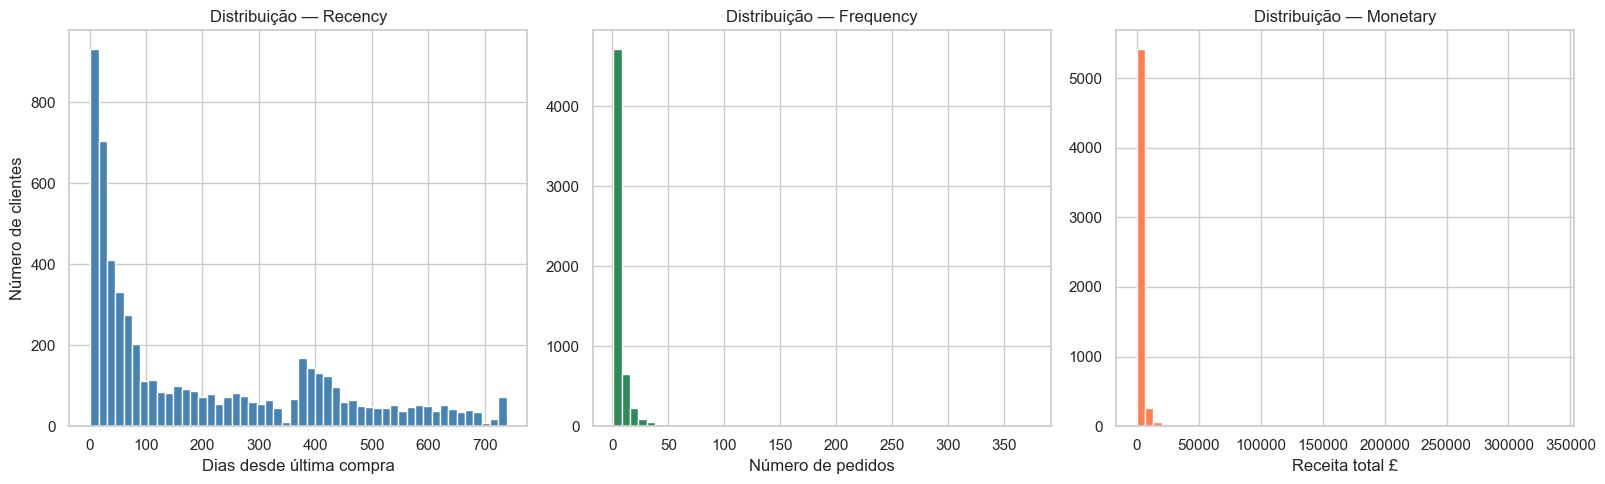

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(rfm['Recency'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição — Recency')
axes[0].set_xlabel('Dias desde última compra')
axes[0].set_ylabel('Número de clientes')

axes[1].hist(rfm['Frequency'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribuição — Frequency')
axes[1].set_xlabel('Número de pedidos')

axes[2].hist(rfm['Monetary'], bins=50, color='coral', edgecolor='white')
axes[2].set_title('Distribuição — Monetary')
axes[2].set_xlabel('Receita total £')

plt.tight_layout()
plt.show()

### Célula 8 — Aplicar transformação logarítmica

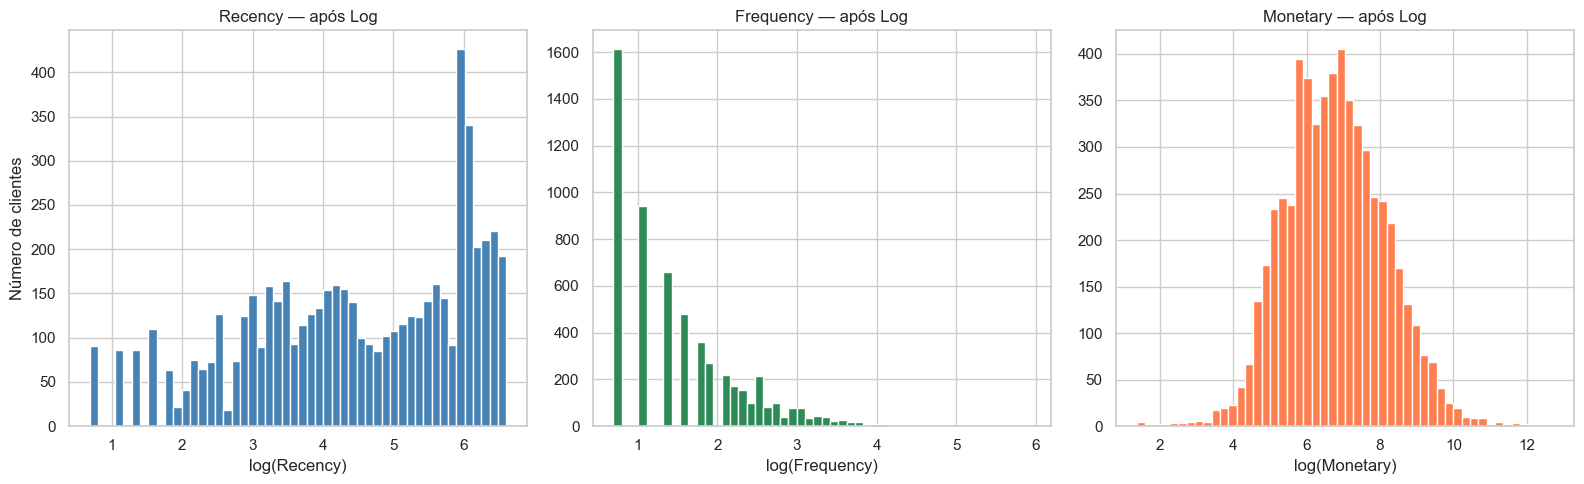

In [8]:
rfm_log = rfm.copy()

rfm_log['Recency_log']   = np.log1p(rfm['Recency'])
rfm_log['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary_log']  = np.log1p(rfm['Monetary'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(rfm_log['Recency_log'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency — após Log')
axes[0].set_xlabel('log(Recency)')
axes[0].set_ylabel('Número de clientes')

axes[1].hist(rfm_log['Frequency_log'], bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Frequency — após Log')
axes[1].set_xlabel('log(Frequency)')

axes[2].hist(rfm_log['Monetary_log'], bins=50, color='coral', edgecolor='white')
axes[2].set_title('Monetary — após Log')
axes[2].set_xlabel('log(Monetary)')

plt.tight_layout()
plt.show()

### Célula 9 — Normalizar com StandardScaler

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']
)

print("Normalização aplicada com sucesso!")
print(f"\nMédias após normalização (devem ser ~0):")
print(rfm_scaled.mean().round(4))
print(f"\nDesvios padrão após normalização (devem ser ~1):")
print(rfm_scaled.std().round(4))

Normalização aplicada com sucesso!

Médias após normalização (devem ser ~0):
Recency_scaled     -0.00
Frequency_scaled    0.00
Monetary_scaled     0.00
dtype: float64

Desvios padrão após normalização (devem ser ~1):
Recency_scaled     1.00
Frequency_scaled   1.00
Monetary_scaled    1.00
dtype: float64


### Célula 10 — Método Elbow — número ideal de clusters

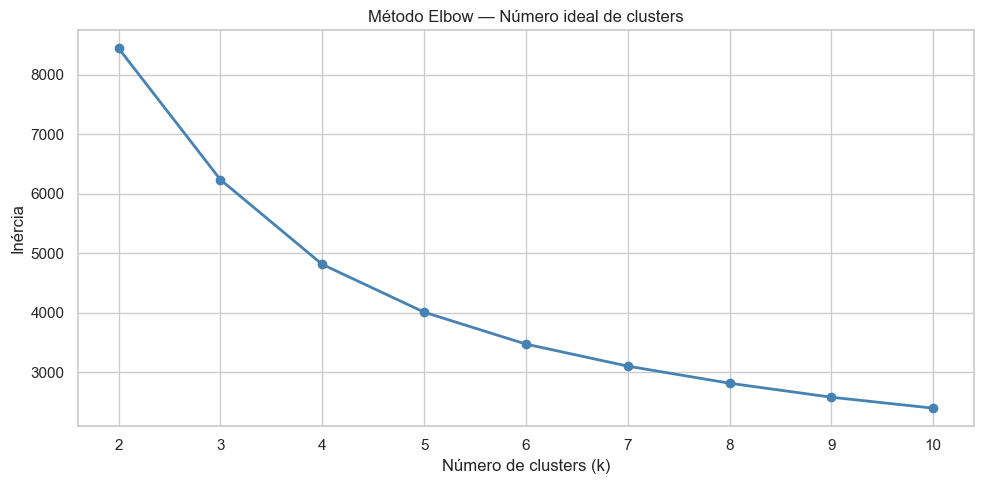


Valores de inércia por k:
k=2: 8440.52
k=3: 6234.14
k=4: 4811.45
k=5: 4008.90
k=6: 3472.60
k=7: 3102.47
k=8: 2815.44
k=9: 2580.53
k=10: 2396.44


In [10]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2, color='steelblue')
plt.title('Método Elbow — Número ideal de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print("\nValores de inércia por k:")
for k, inertia in zip(k_range, inertias):
    print(f"k={k}: {inertia:.2f}")

```
O cotovelo está bem visível em k=4 — é onde a curva muda de íngreme para suave. 
De k=4 para k=5 a queda já é bem menor, e de k=5 em diante a melhoria é marginal.
```
---
```
k=2 → k=3: queda de 2.200 pontos  ← grande ganho
k=3 → k=4: queda de 1.400 pontos  ← bom ganho
k=4 → k=5: queda de   800 pontos  ← ganho menor
k=5 → k=6: queda de   650 pontos  ← diminuindo
```
---
k=4 é o ponto ideal — matematicamente e estrategicamente. 4 segmentos também têm interpretação de negócio clara e acionável.
---

### Célula 11 — Treinar o K-Means com k=4

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"K-Means treinado com k=4")
print(f"\nDistribuição de clientes por cluster:")
print(rfm['Cluster'].value_counts().sort_index())
print(f"\nPercentual por cluster:")
print((rfm['Cluster'].value_counts(normalize=True).sort_index() * 100).round(2))

K-Means treinado com k=4

Distribuição de clientes por cluster:
Cluster
0    1237
1    1968
2    1432
3    1179
Name: count, dtype: int64

Percentual por cluster:
Cluster
0   21.27
1   33.84
2   24.62
3   20.27
Name: proportion, dtype: float64


### Célula 12 — Analisar o perfil de cada cluster

In [12]:
perfil = rfm.groupby('Cluster').agg(
    Clientes=('Customer ID', 'count'),
    Recency_media=('Recency', 'mean'),
    Frequency_media=('Frequency', 'mean'),
    Monetary_media=('Monetary', 'mean'),
    Monetary_total=('Monetary', 'sum')
).round(2)

perfil['% Receita'] = (perfil['Monetary_total'] / perfil['Monetary_total'].sum() * 100).round(2)

print("Perfil dos clusters:")
print('='*75)
print(perfil.to_string())

Perfil dos clusters:
         Clientes  Recency_media  Frequency_media  Monetary_media  Monetary_total  % Receita
Cluster                                                                                     
0            1237          28.55             3.00          806.90       998139.25       6.96
1            1968         393.50             1.38          310.36       610793.45       4.26
2            1432         226.64             5.08         1813.29      2596629.46      18.12
3            1179          27.12            18.86         8589.31     10126800.92      70.66


## Lendo os clusters

| Cluster | Recency  | Frequency   | Monetary | % Receita | Perfil      |
|----------|----------|------------|----------|-----------|------------|
| 3        | 27 dias  | 19 pedidos | £8.589   | 70,66%    | 🏆 VIP |
| 0        | 29 dias  | 3 pedidos  | £807     | 6,96%     | 🌱 Promissor |
| 2        | 227 dias | 5 pedidos  | £1.813   | 18,12%    | ⚠️ Em risco |
| 1        | 394 dias | 1 pedido   | £310     | 4,26%     | 💤 Perdido |

## A narrativa de negócio

Cluster 3 — 1.179 clientes → 70,66% da receita
            Comprou há 27 dias, compra 19x, gasta £8.589
            → Proteger a todo custo

Cluster 0 — 1.237 clientes → apenas 6,96% da receita
            Comprou recentemente mas pouco frequente
            → Desenvolver — tem engajamento, falta frequência

Cluster 2 — 1.432 clientes → 18,12% da receita
            Sumiu há 227 dias mas tinha bom valor
            → Reativar urgente antes de perder definitivamente

Cluster 1 — 1.968 clientes → apenas 4,26% da receita
            Sumiu há 394 dias, comprou pouco
            → Aceitar perda ou campanha de baixo custo

### Célula 13 — Nomear os segmentos

In [13]:
nomes = {
    3: 'VIP',
    0: 'Promissor',
    2: 'Em Risco',
    1: 'Perdido'
}

rfm['Segmento'] = rfm['Cluster'].map(nomes)

print("Segmentos atribuídos:")
print(rfm['Segmento'].value_counts())
print(f"\nExemplo:")
rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Segmento']].head(10)

Segmentos atribuídos:
Segmento
Perdido      1968
Em Risco     1432
Promissor    1237
VIP          1179
Name: count, dtype: int64

Exemplo:


,Customer ID,Recency,Frequency,Monetary,Segmento
0,12346,529,3,170.36,Perdido
1,12347,2,8,4671.93,VIP
2,12348,75,5,1658.40,Em Risco
3,12349,19,3,3678.69,Promissor
4,12350,310,1,294.40,Perdido
5,12351,375,1,300.93,Perdido
6,12352,36,9,1729.54,VIP
7,12353,204,2,406.76,Perdido
8,12354,232,1,1079.40,Perdido
9,12355,214,2,947.61,Em Risco


### Célula 14 — Visualizar os segmentos

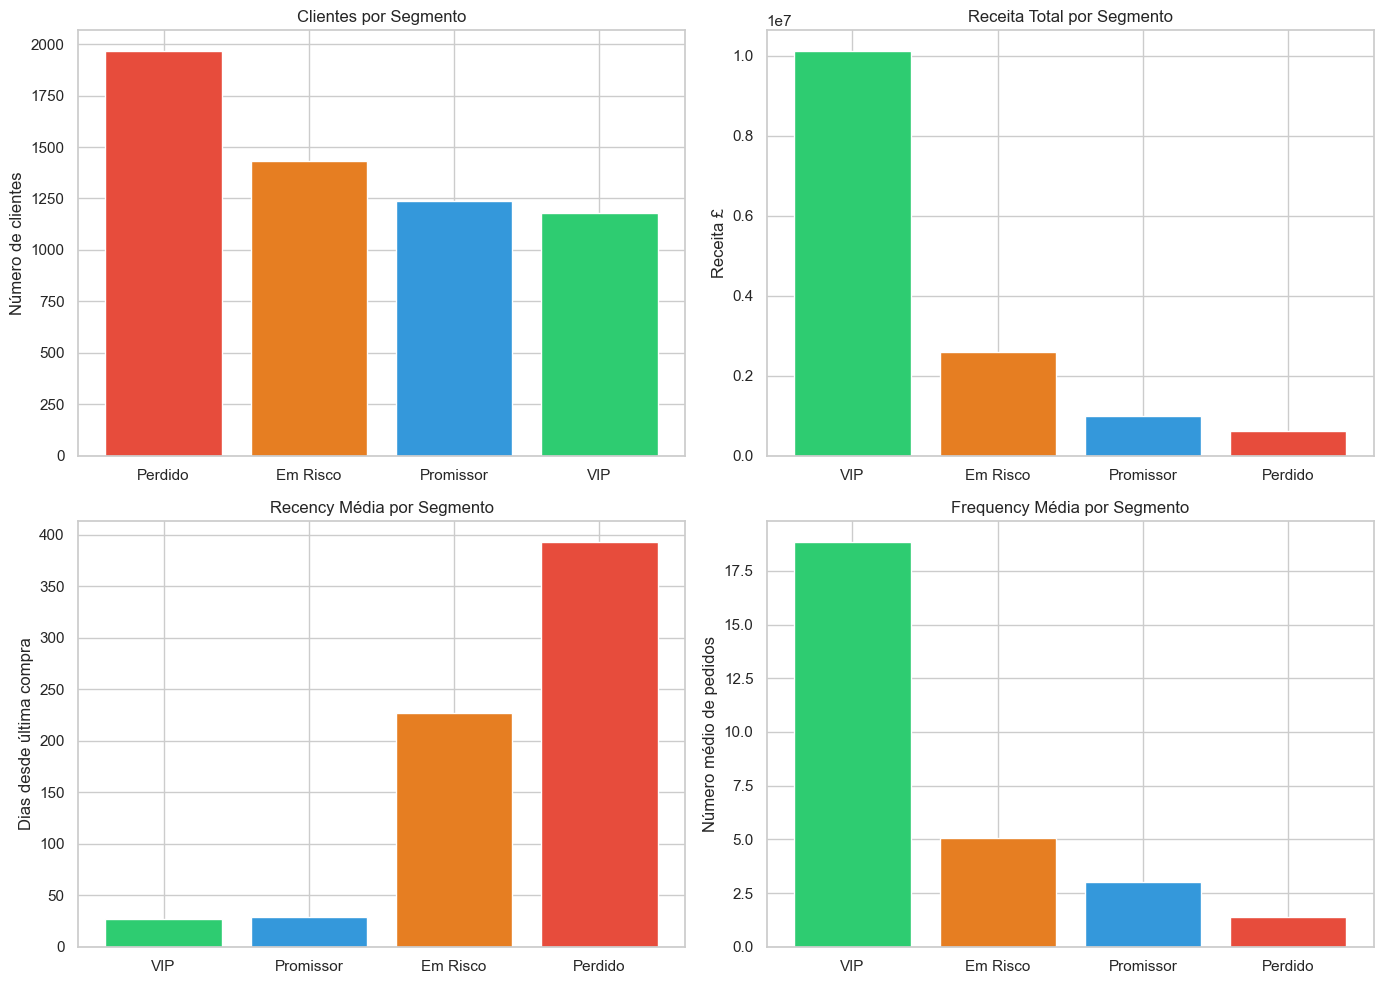

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cores = {'VIP': '#2ecc71', 'Promissor': '#3498db', 
         'Em Risco': '#e67e22', 'Perdido': '#e74c3c'}

# Distribuição de clientes por segmento
contagem = rfm['Segmento'].value_counts()
axes[0,0].bar(contagem.index, contagem.values, 
              color=[cores[s] for s in contagem.index])
axes[0,0].set_title('Clientes por Segmento')
axes[0,0].set_ylabel('Número de clientes')

# Receita por segmento
receita = rfm.groupby('Segmento')['Monetary'].sum().sort_values(ascending=False)
axes[0,1].bar(receita.index, receita.values,
              color=[cores[s] for s in receita.index])
axes[0,1].set_title('Receita Total por Segmento')
axes[0,1].set_ylabel('Receita £')

# Recency média por segmento
recency_media = rfm.groupby('Segmento')['Recency'].mean().sort_values()
axes[1,0].bar(recency_media.index, recency_media.values,
              color=[cores[s] for s in recency_media.index])
axes[1,0].set_title('Recency Média por Segmento')
axes[1,0].set_ylabel('Dias desde última compra')

# Frequency média por segmento
freq_media = rfm.groupby('Segmento')['Frequency'].mean().sort_values(ascending=False)
axes[1,1].bar(freq_media.index, freq_media.values,
              color=[cores[s] for s in freq_media.index])
axes[1,1].set_title('Frequency Média por Segmento')
axes[1,1].set_ylabel('Número médio de pedidos')

plt.tight_layout()
plt.show()

### O que o dashboard revela
Clientes vs Receita — a inversão que justifica o projeto

- Perdido tem mais clientes mas quase zero receita
- VIP tem menos clientes mas domina 70% da receita
- Essa inversão visualmente é o argumento de negócio para qualquer gestor

Recency e Frequency — os separadores naturais

- VIP e Promissor estão no mesmo nível de Recency — ambos compraram recentemente
- O que os separa é a Frequency — VIP compra 19x, Promissor compra 3x
- Essa é a oportunidade: Promissor já está engajado, precisa de incentivo para comprar mais

### Célula 15 — Salvar modelo e dataset segmentado

In [15]:
import pickle

# Salvar modelo K-Means
with open('../models/kmeans_rfm.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Salvar scaler
with open('../models/scaler_rfm.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Salvar dataset segmentado
rfm.to_csv('../data/features/rfm_segmentado.csv', index=False)

print("Arquivos salvos com sucesso!")
print("  → models/kmeans_rfm.pkl")
print("  → models/scaler_rfm.pkl")
print("  → data/features/rfm_segmentado.csv")
print(f"\nDataset final: {rfm.shape[0]:,} clientes x {rfm.shape[1]} colunas")
print(f"Colunas: {list(rfm.columns)}")

Arquivos salvos com sucesso!
  → models/kmeans_rfm.pkl
  → models/scaler_rfm.pkl
  → data/features/rfm_segmentado.csv

Dataset final: 5,816 clientes x 6 colunas
Colunas: ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Segmento']
